# **Etapa de EDA y Preselección de Modelo de entrenamiento:**

### En este Notebook me encargo de hacer la exploracion de datos analíticos. Y para ello, cree un entorno de trabajo llamado Pycaret_env, con sus respectivas librerías, para determinar las metricas de varios modelos de entrenamiento.

## **Observaciones:** Aquí aún no conecte con DagsHub y MlFlow, porque la librería Pycaret tiene conflicto con esas acciones.

In [73]:
# Lectura del archivo base y transformación a un DataFrame
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('E:/CIENCIA DE DATOS E IA/2-SEGUNDO AÑO\SEGUNDO CUATRIMESTRE/2- LABORATORIO DE MINERIA Y DATOS/Proyecto_AndesLink/data/churn_sintetico.csv')
print(df.head())

   tenure_months  monthly_charge  total_charges  support_tickets  \
0              7           58.23         326.50                2   
1             56           56.75        3154.21                0   
2             48           78.84        3864.31                3   
3             32           79.74        2511.40                0   
4             32           55.37        1735.51                3   

   late_payments  avg_monthly_usage_gb contract_type payment_method  \
0              1                 81.83       mensual  transferencia   
1              2                 96.52         anual         debito   
2              2                 93.60       bianual       efectivo   
3              0                 28.95       bianual         debito   
4              0                126.90         anual       efectivo   

  internet_service  has_streaming  has_security_pack  num_products  region  \
0            cable              0                  1             3  centro   
1       

In [74]:
# Ver la dimención del DataFrame
df.shape 

(5000, 16)

In [75]:
# Corroborar que no haya datos nulos
df.isnull().sum()

tenure_months           0
monthly_charge          0
total_charges           0
support_tickets         0
late_payments           0
avg_monthly_usage_gb    0
contract_type           0
payment_method          0
internet_service        0
has_streaming           0
has_security_pack       0
num_products            0
region                  0
customer_age            0
is_promo                0
churn                   0
dtype: int64

In [76]:
# Corroborar que no haya datos duplicados
df.duplicated().sum()

0

In [77]:
# Ver entre que rangos tenemos como clientes y de paso verificar que no haya edades incongruentes
edad_maxima = df['customer_age'].max()
edad_minima = df['customer_age'].min()
print(f"La edad máxima de los clientes: {edad_maxima} años")
print(f"La edad máxima de los clientes: {edad_minima} años")

La edad máxima de los clientes: 78 años
La edad máxima de los clientes: 18 años


In [80]:
# Al observar la cantidad de clientes entre los que permanecen y los que abandonaron, se identifica un abandono cercano a 1/3 del total o cercao al 34%
Abandono_de_servicios = df['churn'].value_counts()
print (f"Cantidad Total de Clientes que Abandonaron (1)")
print(Abandono_de_servicios)

Cantidad Total de Clientes que Abandonaron (1)
churn
0    3298
1    1702
Name: count, dtype: int64


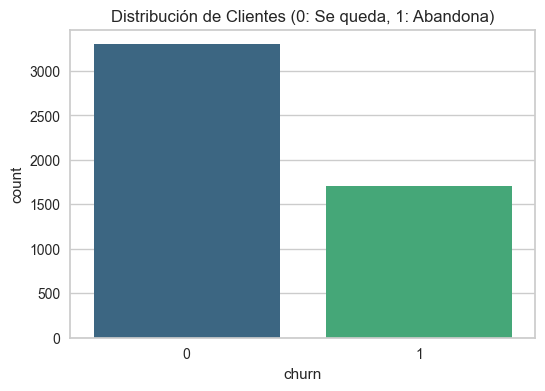

In [89]:
# Visualizar la distribución de Churn
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='churn', palette='viridis')
plt.title('Distribución de Clientes (0: Se queda, 1: Abandona)')
plt.show()

In [79]:
# Ahora veamos en porcentaje el abandono según los servicios contratados
# Como observación me encontre con clientes de categoría ningúno.
# Resulto que la categoria ninguno, eran de clientes que contrataban otros tipos de servicios, la de streaming y pack de seguridad
print (f"% de Abandono según el Tipo de Servicio")
pd.crosstab(df['internet_service'], df['churn'], normalize='index') * 100


% de Abandono según el Tipo de Servicio


churn,0,1
internet_service,,
cable,65.214336,34.785664
fibra,73.169643,26.830357
movil,49.100000,50.900000
ninguno,71.216617,28.783383


In [81]:
# En este caso vemos que el streaming casi no impacta en el abandono.
print (f"% de Abandono según el Tipo de Servicio")
pd.crosstab(df['has_security_pack'], df['churn'], normalize='index') * 100

% de Abandono según el Tipo de Servicio


churn,0,1
has_security_pack,,
0,64.928292,35.071708
1,66.839570,33.160430


In [82]:
# En este caso vemos que el streaming casi no impacta en el abandono.
print (f"% de Abandono según el Tipo de Servicio")
pd.crosstab(df['has_streaming'], df['churn'], normalize='index') * 100

% de Abandono según el Tipo de Servicio


churn,0,1
has_streaming,,
0,65.421687,34.578313
1,66.227545,33.772455


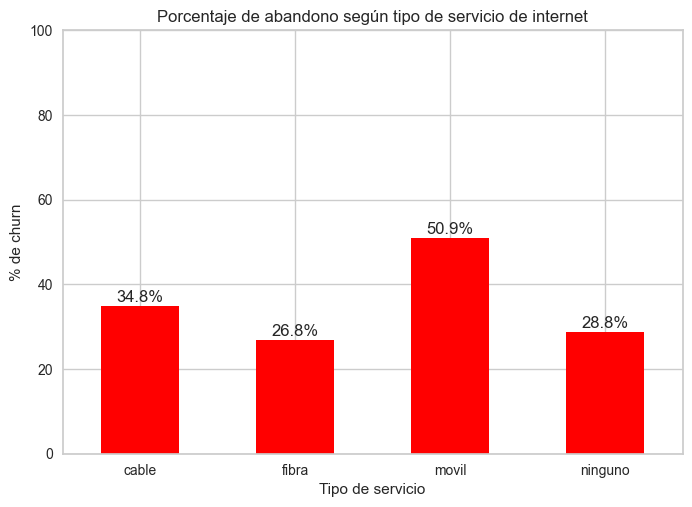

In [ ]:
# Gráfico de Barras 

import matplotlib.pyplot as plt

churn_pct = df.groupby('internet_service')['churn'].mean() * 100

churn_pct.plot(kind='bar', color='red')

plt.title('Porcentaje de abandono según tipo de servicio de internet')
plt.ylabel('% de churn')
plt.xlabel('Tipo de servicio')
plt.xticks(rotation=0)
plt.ylim(0, 100)

# Mostrar valores arriba de cada barra
for i, v in enumerate(churn_pct):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.show()

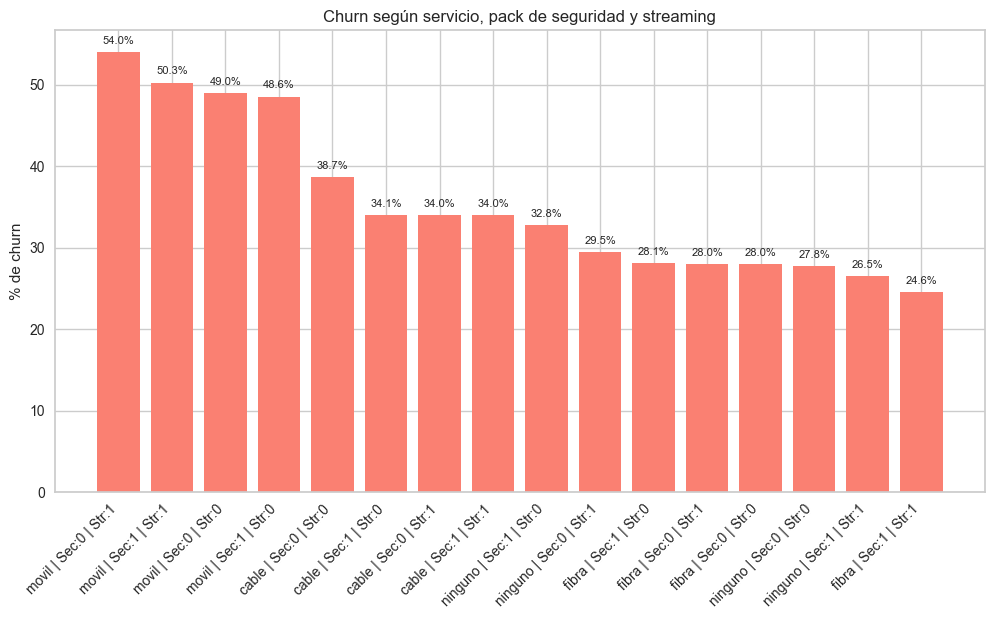

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

tabla = pd.crosstab(
    [df['internet_service'], df['has_security_pack'], df['has_streaming']],
    df['churn'],
    normalize='index'
) * 100

churn_data = tabla[1].reset_index()

# Crear etiqueta combinada
churn_data['grupo'] = (
    churn_data['internet_service'] + 
    ' | Sec:' + churn_data['has_security_pack'].astype(str) + 
    ' | Str:' + churn_data['has_streaming'].astype(str)
)

# Ordenar
churn_data = churn_data.sort_values(1, ascending=False)

plt.figure(figsize=(12,6))
plt.bar(churn_data['grupo'], churn_data[1], color='salmon')

plt.xticks(rotation=45, ha='right')
plt.ylabel('% de churn')
plt.title('Churn según servicio, pack de seguridad y streaming')

for i, v in enumerate(churn_data[1]):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=8)

plt.show()

# **Primeras Observaciones:**
### Tener o no tener el paquete de seguridad o el servicio de Streaming no parece influir en que el cliente se quede o se vaya.

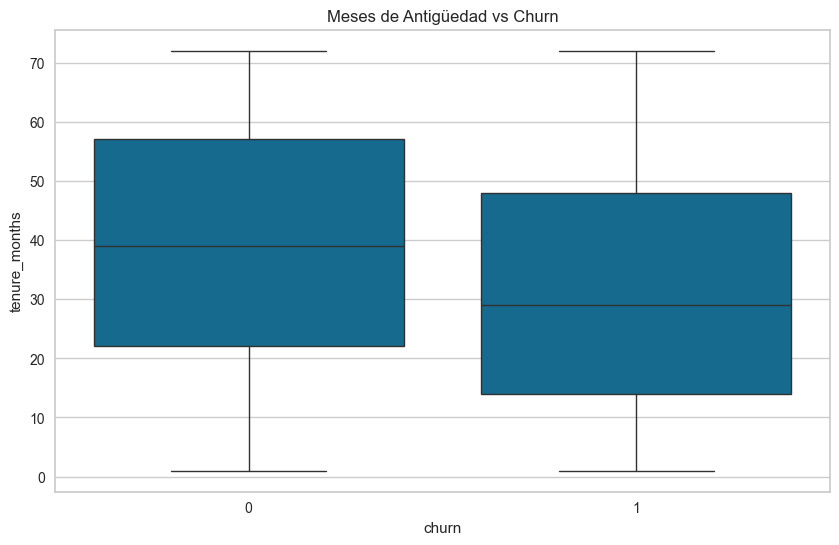

In [90]:
# Relación: Antigüedad vs Churn (Hipótesis: ¿los nuevos se van más?)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='churn', y='tenure_months')
plt.title('Meses de Antigüedad vs Churn')
plt.show()

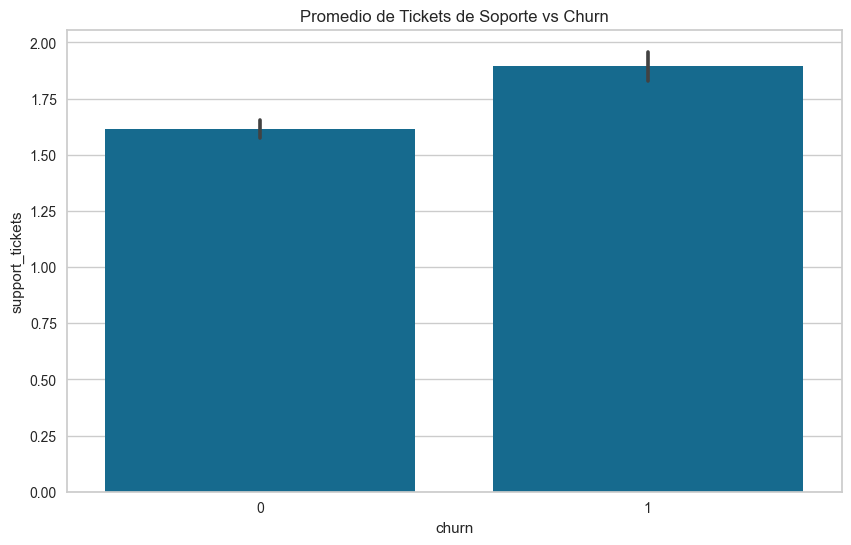

In [91]:
# Relación: Tickets de Soporte vs Churn
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='churn', y='support_tickets')
plt.title('Promedio de Tickets de Soporte vs Churn')
plt.show()

# **Observaciones y Conclusión:**

## 1. Antigüedad del cliente
### Los clientes que abandonan presentan una menor antigüedad. La mediana de permanencia es significativamente más baja (30 meses o 2 años y medio) en comparación con los clientes que permanecen (40 meses)
### Esto indica que el riesgo de churn es mayor en las primeras etapas del ciclo de vida del cliente, especialmente durante los primeros 2–3 años.

## 2. Tickets de soporte
### Los clientes que abandonan generan más interacciones con soporte (1.9 tickets en promedio) que aquellos que se quedan (1.6).
### Esto sugiere que una mayor fricción o problemas en el servicio están asociados con una mayor probabilidad de abandono.

In [93]:
from pycaret.classification import *

# Configuración SIN MLflow, para evitar errores de incompatibilidad con PyCaret(log_experiment=False)
clf_setup = setup(
    data=df, 
    target='churn', 
    normalize=True, 
    session_id=42, 
    log_experiment=False  # Esto apaga el motor que pide pkg_resources, lo configure porque no lograba correr el código
)

# Comparar modelos
# Esto mostrará la tabla de resultados
best_model = compare_models()

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(5000, 16)"
4,Transformed data shape,"(5000, 27)"
5,Transformed train set shape,"(3500, 27)"
6,Transformed test set shape,"(1500, 27)"
7,Numeric features,11
8,Categorical features,4
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7229,0.7622,0.4559,0.6290,0.5281,0.3390,0.3481,2.3090
lda,Linear Discriminant Analysis,0.7217,0.7614,0.4610,0.6249,0.5298,0.3386,0.3470,0.2260
ridge,Ridge Classifier,0.7209,0.7614,0.4400,0.6296,0.5172,0.3296,0.3405,0.2120
gbc,Gradient Boosting Classifier,0.7169,0.7507,0.4366,0.6193,0.5113,0.3206,0.3307,0.8630
rf,Random Forest Classifier,0.7160,0.7342,0.4148,0.6252,0.4980,0.3113,0.3244,0.7700
ada,Ada Boost Classifier,0.7114,0.7472,0.4517,0.6035,0.5156,0.3163,0.3236,0.4190
et,Extra Trees Classifier,0.7060,0.7202,0.4248,0.5962,0.4952,0.2963,0.3052,0.7550
lightgbm,Light Gradient Boosting Machine,0.7031,0.7297,0.4400,0.5869,0.5018,0.2968,0.3036,0.7750
svm,SVM - Linear Kernel,0.6874,0.7000,0.4610,0.5501,0.4996,0.2756,0.2789,0.2020
nb,Naive Bayes,0.6863,0.7465,0.6633,0.5325,0.5899,0.3411,0.3472,0.1820


# **Selección del Modelo de Entrenamiento:** 

# **NAIVE BAYES**

## **Captura la Mayoría de los casos de fuga con el (Recall)**
### El modelo Naive Bayes presenta un Recall de 0.6633, el cual es significativamente superior al de todos los demás modelos en la lista (que rondan el 0.43 - 0.46).
### Este modelo es capaz de identificar correctamente al 66% de los clientes que realmente se van a ir.
### En cambio un modelo como el de Regresión Logística (lr), aunque tiene mejor Accuracy, solo detecta al 45% de los desertores, dejando que más de la mitad se escapen sin ser detectados.

## **El Mejor Equilibrio Real (F1-Score)**
### Aquí también gana el F1-Score más alto (0.5899).
### El F1-Score es la media armónica entre Precisión y Recall. Al ser el más alto, nos indica que Naive Bayes ofrece el mejor balance para no perder de vista a los clientes en riesgo sin disparar demasiadas falsas alarmas.

## **Estabilidad**

### **Kappa (0.3411):** Es uno de los valores más altos de la tabla, indicando que las predicciones del modelo tienen una concordancia y no fruto del azar, especialmente considerando el desbalance de clases que suele haber en datos de fuga.

### **Tiempo de Entrenamiento (0.18s):** Es extremadamente rápido, lo que facilita su re-entrenamiento frecuente si los datos de comportamiento de los usuarios cambian.

## **Optimización de Costos de Negocio**
### Costo de Falso Negativo (Alto): Perder a un cliente porque el modelo no lo detectó. El costo es la pérdida total del valor de vida del cliente.
### Costo de Falso Positivo (Bajo): Darle un descuento o llamar a un cliente que en realidad no pensaba irse. El costo es solo el valor de la promoción o el tiempo de la llamada.
### **Conclusión:** Dado que el costo de perder un cliente es mucho mayor al costo de una acción preventiva, priorizar el Recall de Naive Bayes, es la decisión financieramente más inteligente.
